<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/OlS_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OLS SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     1591.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.42e-96
Time:                        05:39:57   Log-Likelihood:                -489.75
No. Observations:                 200   AIC:                             983.5
Df Residuals:                     198   BIC:                             990.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7546      0.464      3.

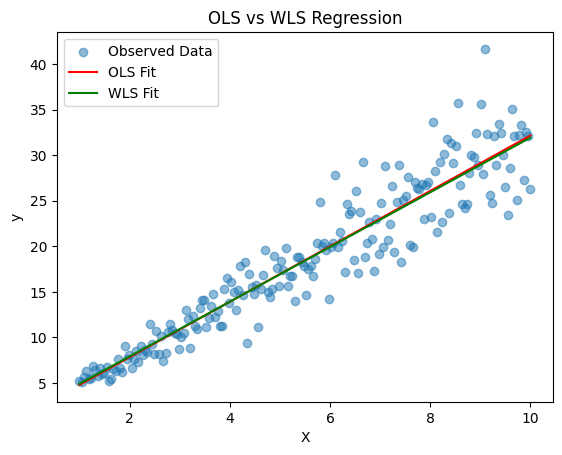

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
# Step 1: Generate heteroscedastic data
np.random.seed(42)
n = 200
X = np.linspace(1, 10, n)
X_mat = sm.add_constant(X)
# Heteroscedastic error variance
sigma = 0.5 * X
errors = np.random.normal(0, sigma)
y = 2 + 3 * X + errors
# Step 2: Ordinary Least Squares (OLS)
ols_model = sm.OLS(y, X_mat).fit()
print("OLS SUMMARY")
print(ols_model.summary())
# Step 3: Breusch–Pagan Test
bp_test = het_breuschpagan(ols_model.resid, X_mat)
labels = ['LM Statistic', 'LM p‐value', 'F Statistic', 'F p‐value']
print("\nBreusch–Pagan Test Results:")
print(dict(zip(labels, bp_test)))
# Step 4: Define weights (inverse variance)
weights = 1 / (X ** 2)
# Step 5: Weighted Least Squares (WLS)
wls_model = sm.WLS(y, X_mat, weights=weights).fit()
print("\nWLS SUMMARY")
print(wls_model.summary())
# Step 6: Compare standard errors
print("\nOLS Standard Errors:", ols_model.bse)
print("WLS Standard Errors:", wls_model.bse)
# Step 7: Visualization
plt.scatter(X, y, alpha=0.5, label="Observed Data")
plt.plot(X, ols_model.predict(X_mat), color='red', label="OLS Fit")
plt.plot(X, wls_model.predict(X_mat), color='green', label="WLS Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("OLS vs WLS Regression")
plt.legend()
plt.show()
